# Relação entre as colunas do Abalone

1. Mapa de calor de correlação (colunas numéricas)
2. Matriz de dispersão (todas contra todas), colorida por `sex`
3. Boxplots de cada coluna numérica por sexo, um painel para cada tipo
4. Relação entre `sex` e `type`

In [1]:
# Instale uma vez, se precisar: !pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
CAMINHO = "abalone_dataset.csv"  # troque pelo caminho do seu arquivo

df = pd.read_csv(CAMINHO)

colunas_categoricas = [c for c in ["sex", "type"] if c in df.columns]
colunas_numericas = [c for c in df.columns if c not in colunas_categoricas]
df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type
0,M,0.535,0.420,0.150,0.6995,0.2575,0.1530,0.2400,3
1,I,0.510,0.380,0.115,0.5155,0.2150,0.1135,0.1660,1
2,I,0.185,0.130,0.045,0.0290,0.0120,0.0075,0.0095,1
3,M,0.550,0.450,0.170,0.8100,0.3170,0.1570,0.2200,3
4,I,0.535,0.415,0.150,0.5765,0.3595,0.1350,0.2250,1


## 1. Correlação entre as colunas numéricas

Valores perto de 1 indicam que as colunas crescem juntas; perto de 0, que não há relação linear.

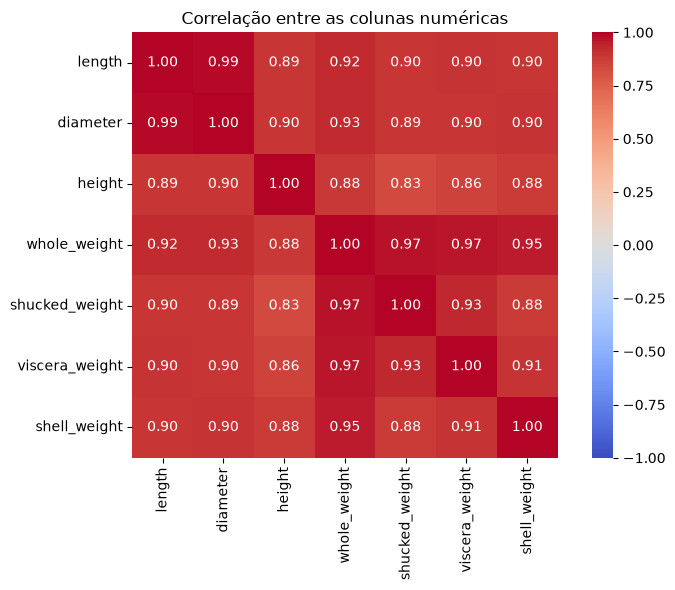

In [3]:
corr = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlação entre as colunas numéricas")
plt.tight_layout()
plt.show()

## 2. Matriz de dispersão (cada coluna contra todas as outras)

A diagonal mostra a distribuição de cada coluna. Pode levar alguns segundos para carregar.

M    111
I    111
F    111
dtype: int64
type    1    2    3
sex                
F     111  111  111
I     111  111  111
M     111  111  111


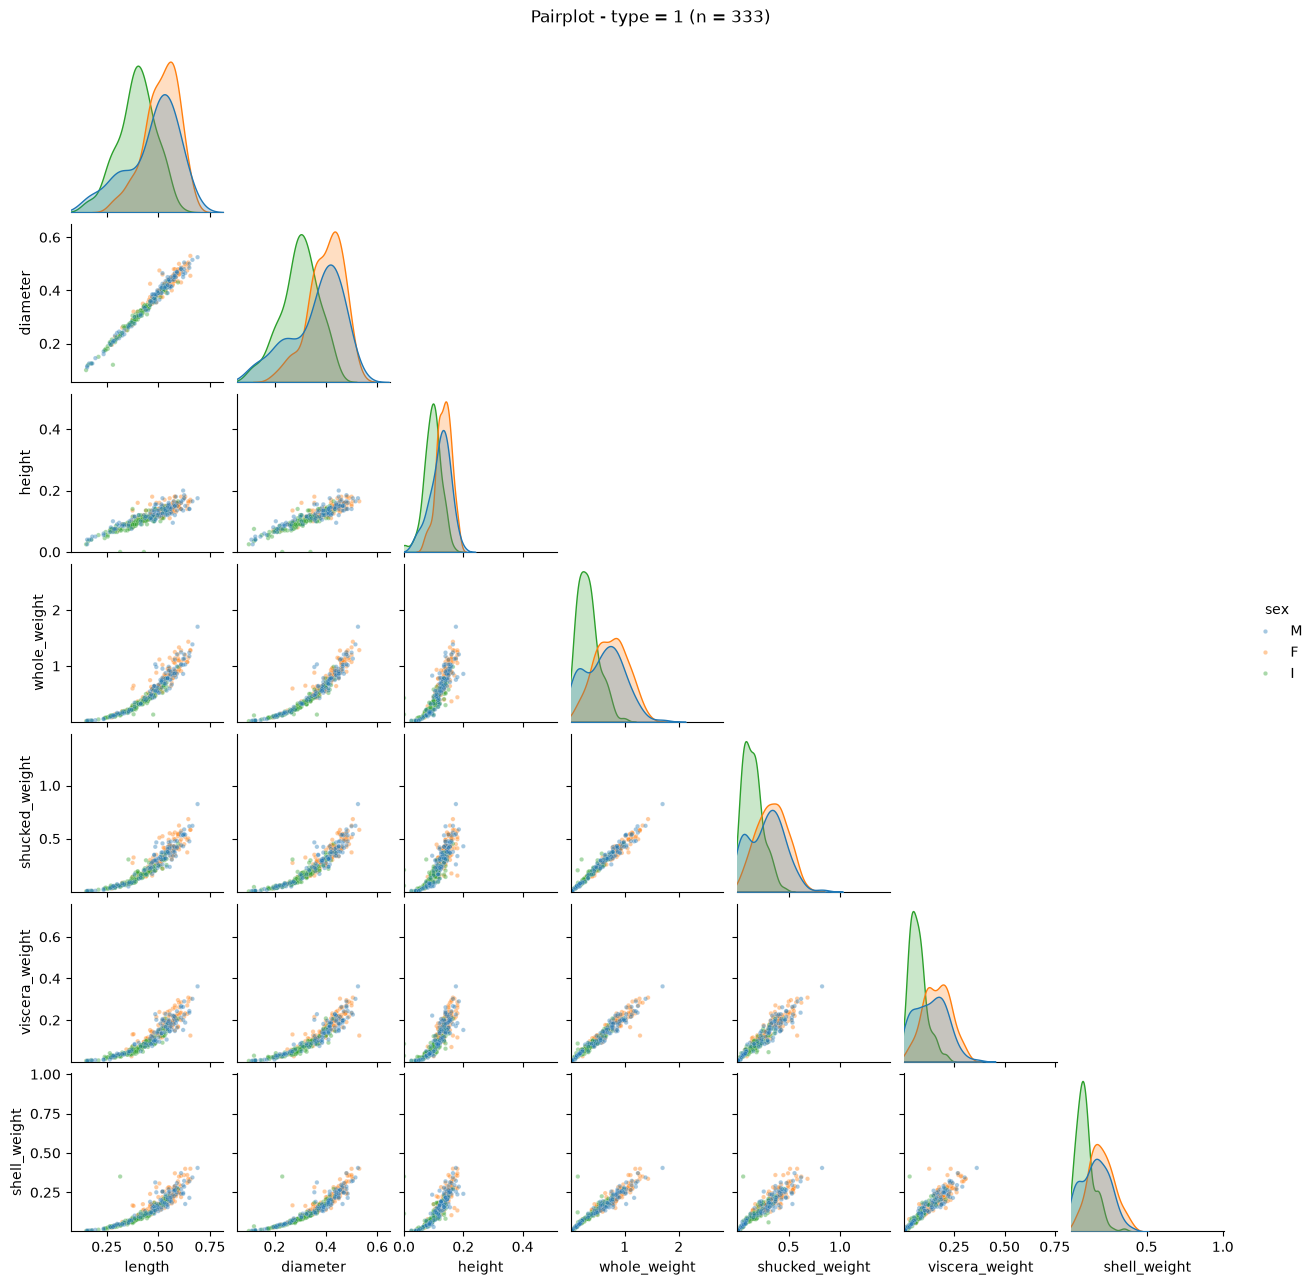

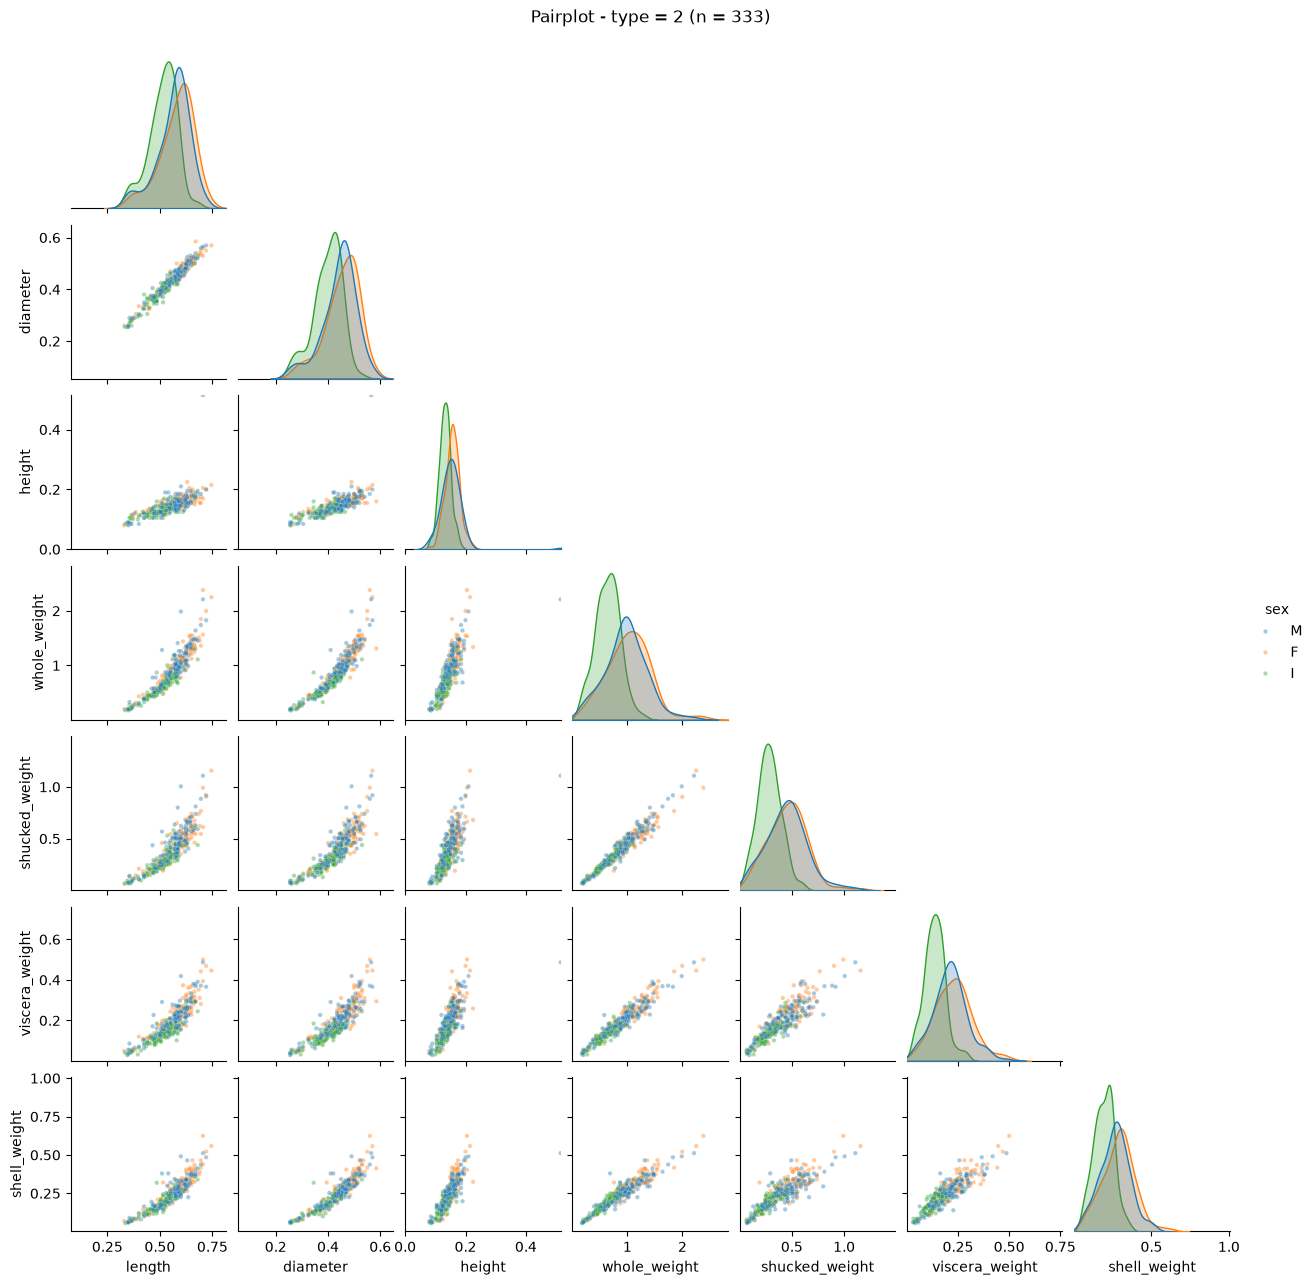

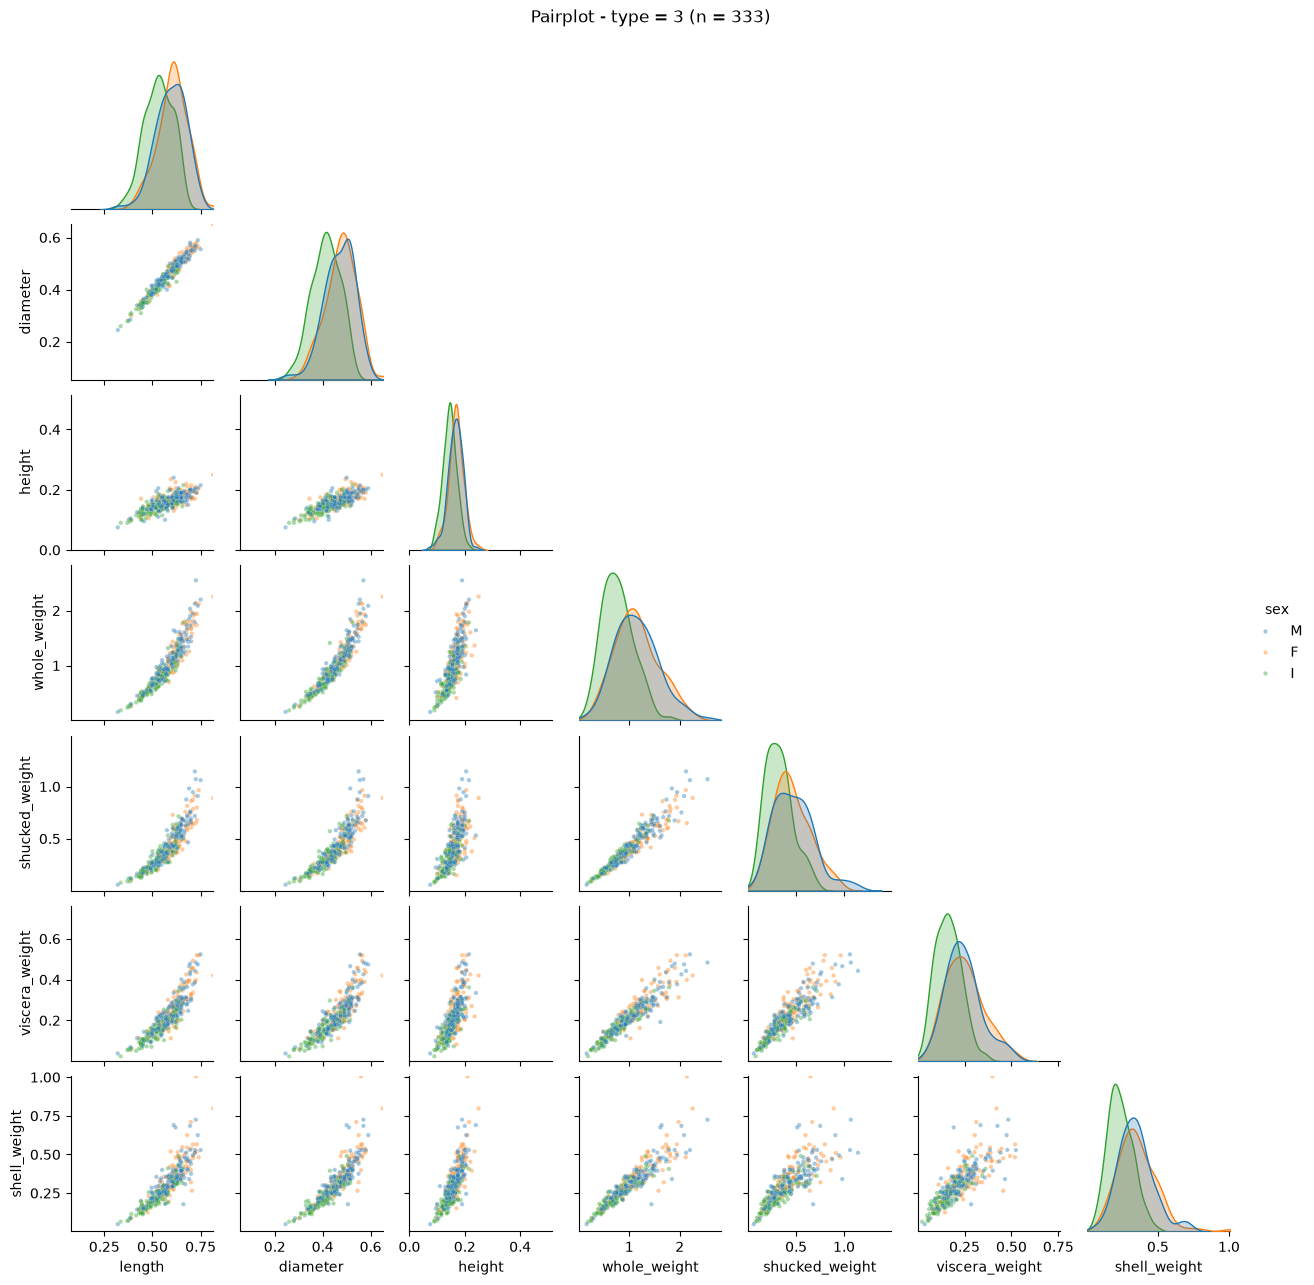

In [4]:
# Menor quantidade de linhas de cada sexo entre os três tipos
n_por_sexo = pd.Series(df.groupby(["sex", "type"]).size().min(), index=df["sex"].unique())
print(n_por_sexo)

# Sorteia essa quantidade de cada sexo em cada tipo
partes = [
    g.sample(n=n_por_sexo[sexo], random_state=42)
    for (sexo, tipo), g in df.groupby(["sex", "type"])
]
df_bal = pd.concat(partes)

print(pd.crosstab(df_bal["sex"], df_bal["type"]))  # confere o balanceamento

paleta = {"M": "tab:blue", "F": "tab:orange", "I": "tab:green"}

for tipo, df_tipo in df_bal.groupby("type"):
    g = sns.pairplot(df_tipo, vars=colunas_numericas, hue="sex",
                     hue_order=["M", "F", "I"], palette=paleta,
                     corner=True, plot_kws={"alpha": 0.4, "s": 10}, height=1.8)
    g.figure.suptitle(f"Pairplot - type = {tipo} (n = {len(df_tipo)})", y=1.02)
    for ax in g.axes.flatten():
        if ax is None:
            continue
        xlab, ylab = ax.get_xlabel(), ax.get_ylabel()
        if xlab in colunas_numericas:
            ax.set_xlim(df[xlab].min(), df[xlab].max())
        if ylab in colunas_numericas and ylab != xlab:
            ax.set_ylim(df[ylab].min(), df[ylab].max())
    plt.show()

Separado por sexo

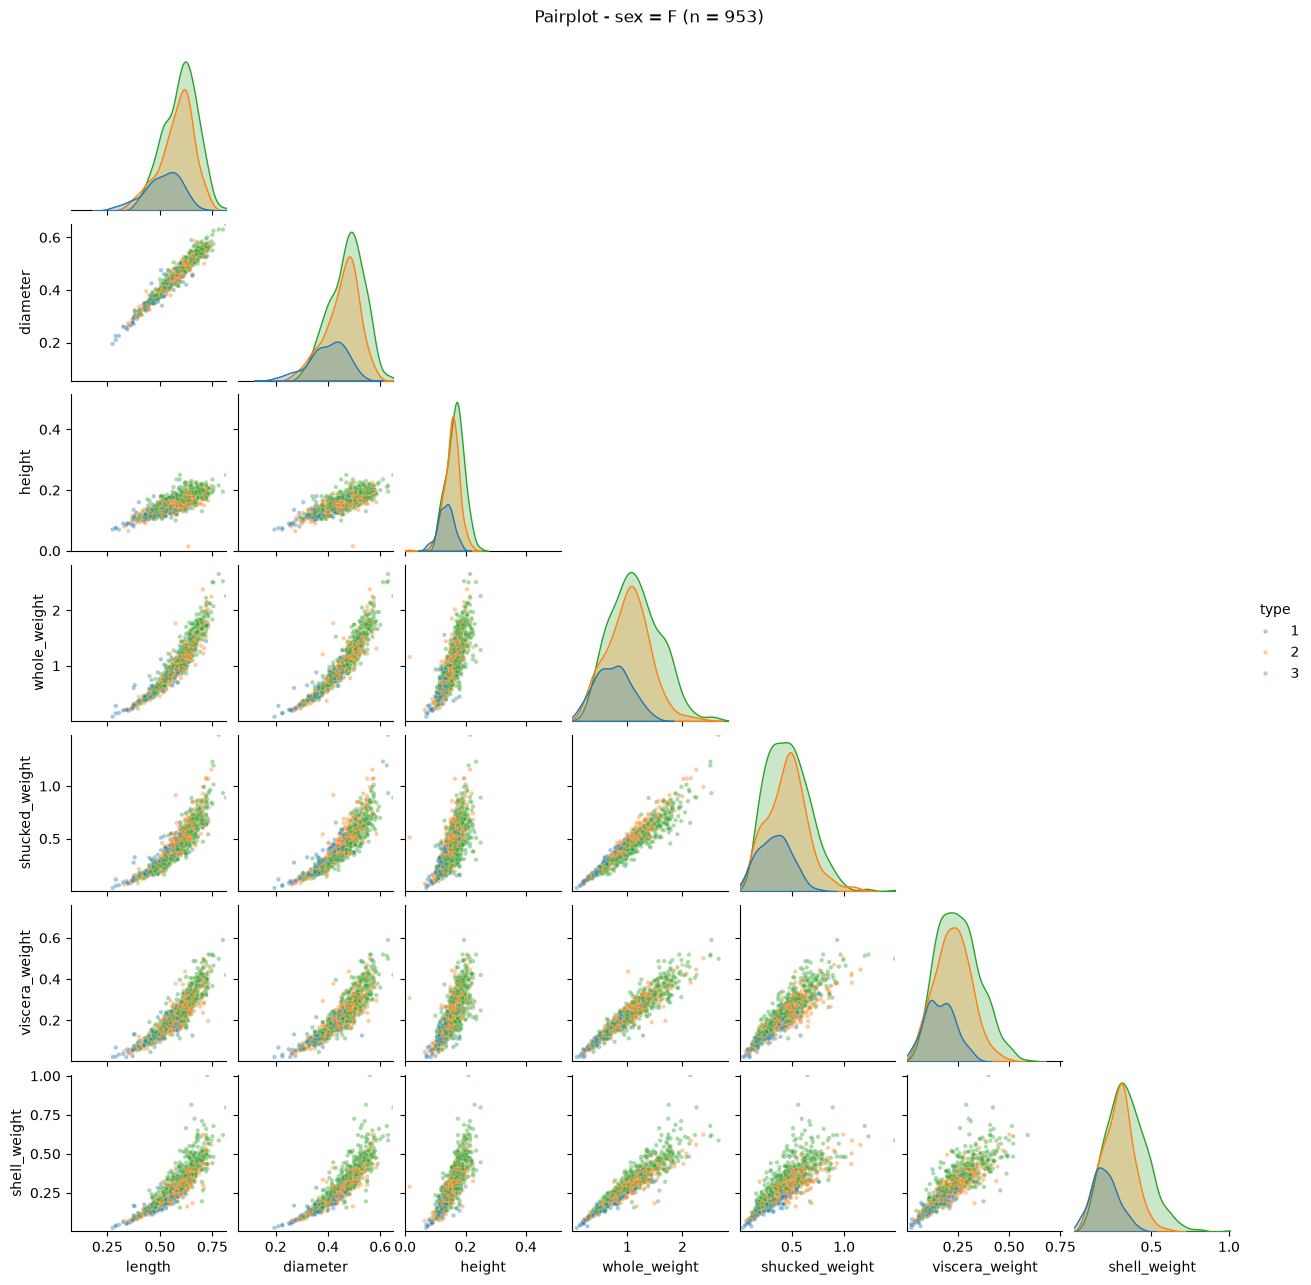

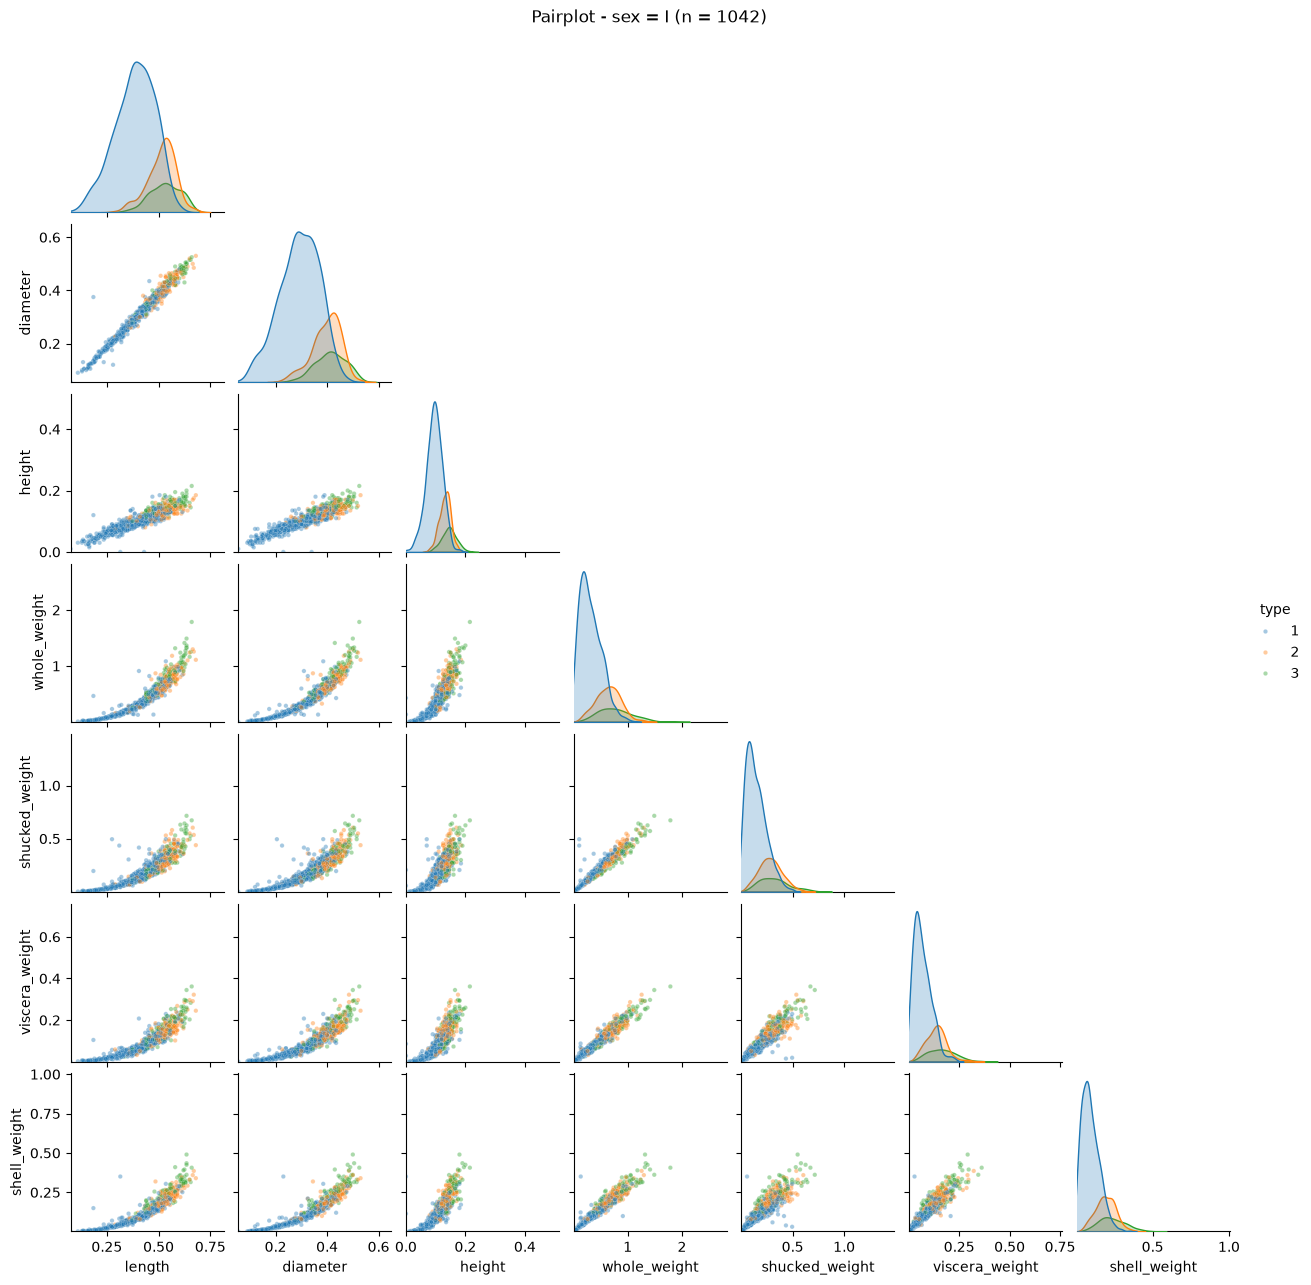

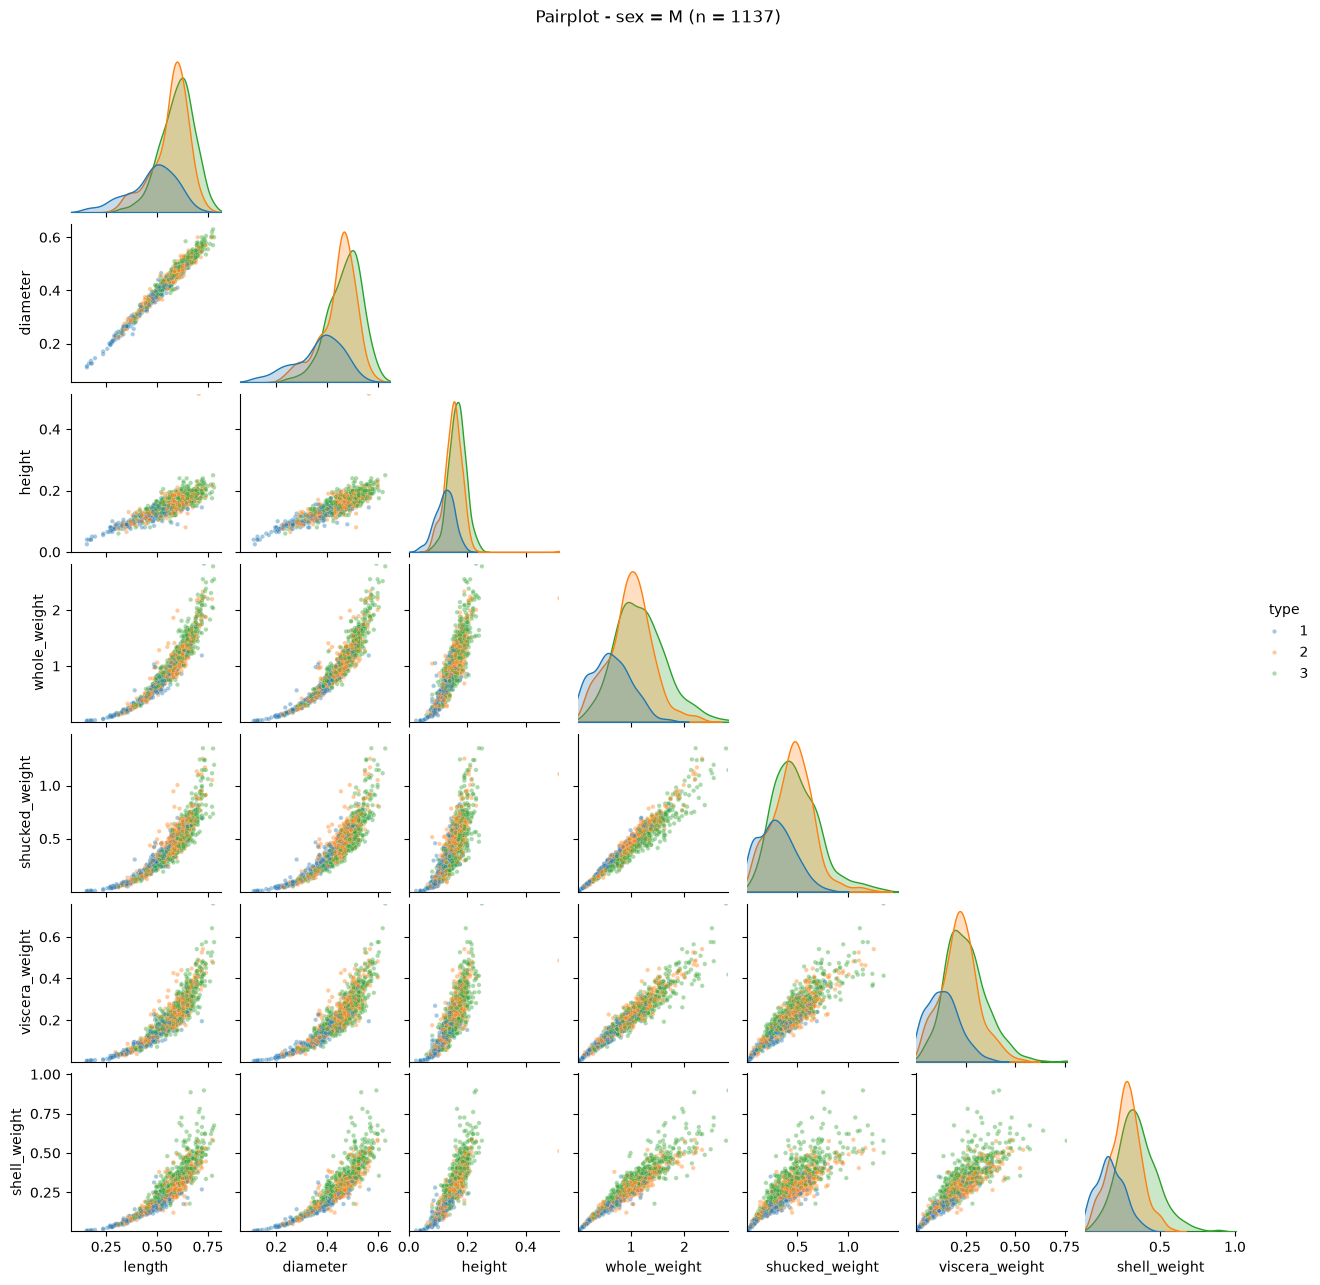

In [5]:
vars_num = [c for c in colunas_numericas if c != "type"]

paleta = {1: "tab:blue", 2: "tab:orange", 3: "tab:green"}

for sexo, df_sexo in df.groupby("sex"):
    g = sns.pairplot(df_sexo, vars=vars_num, hue="type",
                     hue_order=[1, 2, 3], palette=paleta,
                     corner=True, plot_kws={"alpha": 0.4, "s": 10}, height=1.8)
    g.figure.suptitle(f"Pairplot - sex = {sexo} (n = {len(df_sexo)})", y=1.02)
    for ax in g.axes.flatten():
        if ax is None:
            continue
        xlab, ylab = ax.get_xlabel(), ax.get_ylabel()
        if xlab in vars_num:
            ax.set_xlim(df[xlab].min(), df[xlab].max())
        if ylab in vars_num and ylab != xlab:
            ax.set_ylim(df[ylab].min(), df[ylab].max())
    plt.show()

## 3. Boxplots de cada coluna numérica por sexo, um painel para cada tipo

Para cada coluna, 3 boxplots lado a lado (`type` 1, 2 e 3), cada um comparando F, I e M. O eixo y é compartilhado para facilitar a comparação.

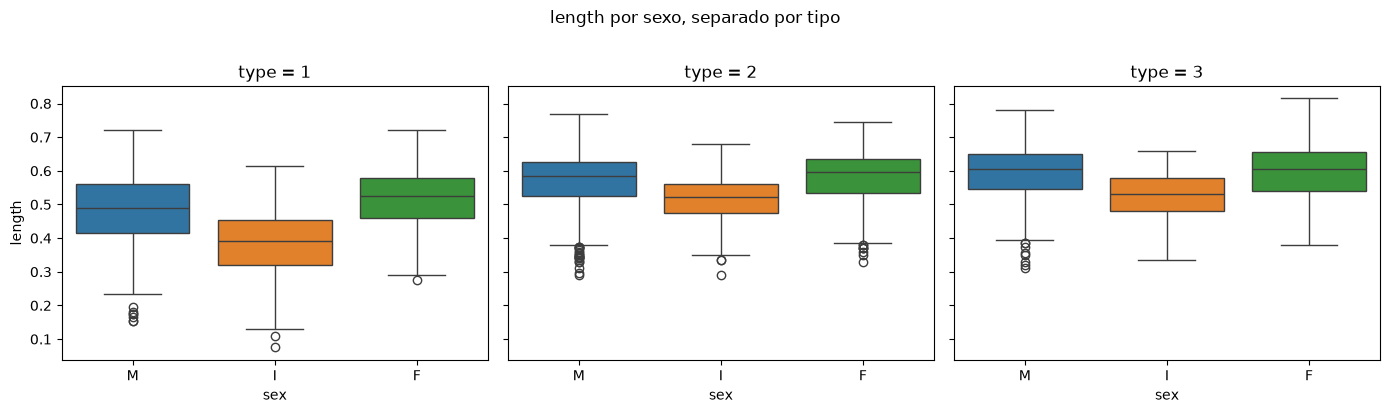

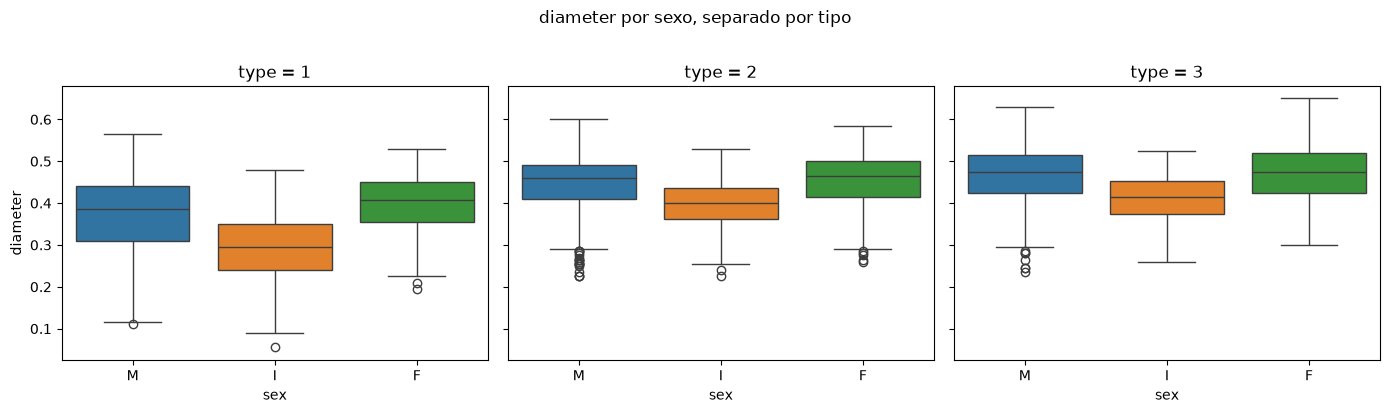

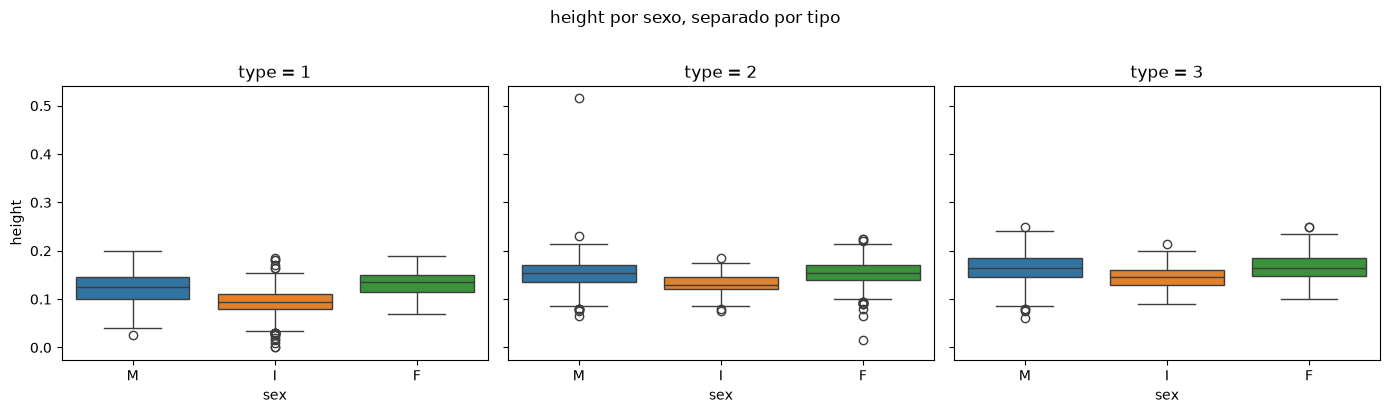

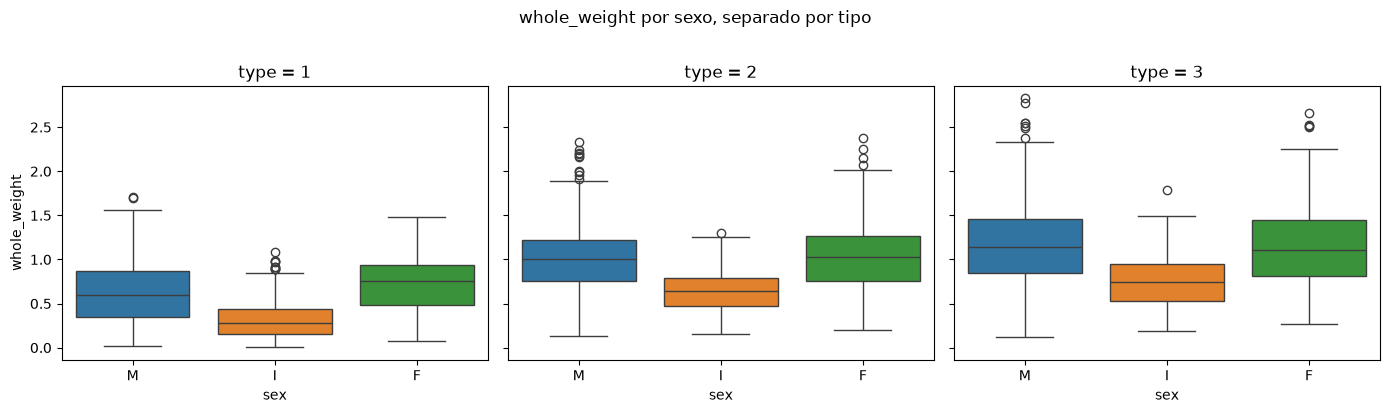

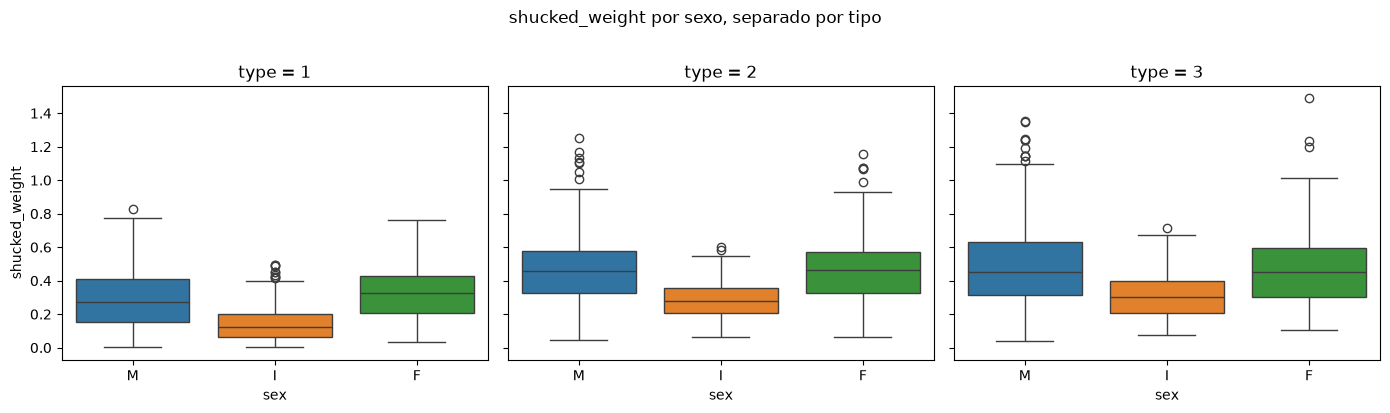

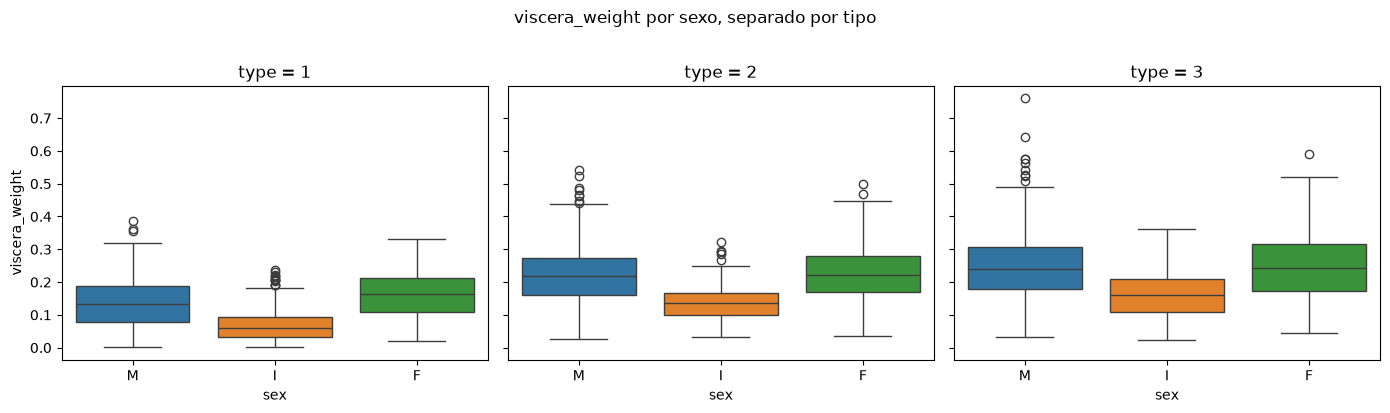

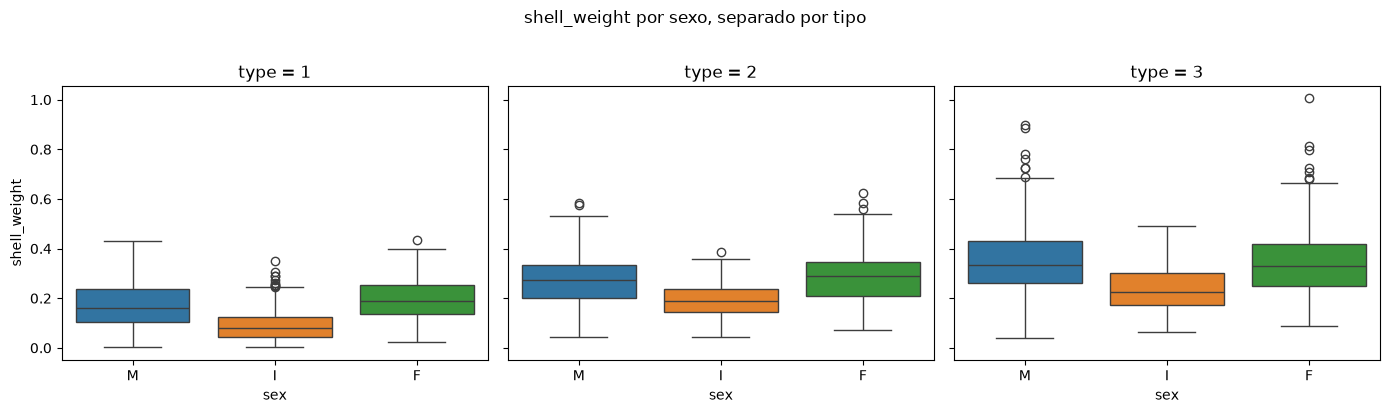

In [6]:
ordem_sexo = ["M", "I", "F"]
tipos = sorted(df["type"].unique())

for col in colunas_numericas:
    fig, axes = plt.subplots(1, len(tipos), figsize=(14, 4), sharey=True)
    for ax, t in zip(axes, tipos):
        sns.boxplot(data=df[df["type"] == t], x="sex", y=col, order=ordem_sexo,
                    hue="sex", hue_order=ordem_sexo, legend=False, ax=ax)
        ax.set_title(f"type = {t}")
        ax.set_xlabel("sex")
    axes[0].set_ylabel(col)
    for ax in axes[1:]:
        ax.set_ylabel("")
    fig.suptitle(f"{col} por sexo, separado por tipo", y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Relação entre `sex` e `type`

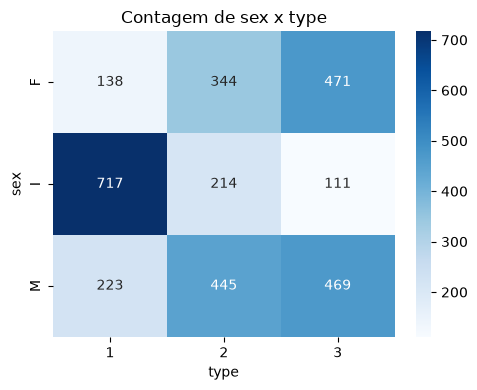

In [7]:
if len(colunas_categoricas) == 2:
    tabela = pd.crosstab(df["sex"], df["type"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(tabela, annot=True, fmt="d", cmap="Blues")
    plt.title("Contagem de sex x type")
    plt.tight_layout()
    plt.show()
else:
    print("O arquivo não tem as duas colunas categóricas (sex e type).")